# BOxCrete: Slump Prediction

This notebook demonstrates slump prediction for concrete mixes using a
Gaussian Process model with a domain-specific derived feature.

The model automatically appends the HRWR-to-binder ratio to the raw
composition inputs via an `AppendDerivedFeatures` input transform.
This derived feature encodes admixture dosage relative to total binder
content — a key determinant of concrete workability — as a ratio that
stationary GP kernels cannot discover from the raw ingredient amounts alone.
Adding this single feature improves LOO-CV R² from ~0.30 to ~0.47.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*findfont.*')

import torch
import matplotlib.pyplot as plt

from boxcrete.utils import (
    load_concrete_strength, SLUMP_Y_COLUMNS, DEFAULT_X_COLUMNS,
)
from boxcrete.models import SustainableConcreteModel
from boxcrete.plotting import plot_slump_calibration, plot_feature_importance

torch.manual_seed(42)
print("Imports complete.")

Imports complete.


## 1. Load Data

In [2]:
data = load_concrete_strength(Y_columns=SLUMP_Y_COLUMNS)
X_slump, Y_slump, Yvar_slump, bounds_slump = data.slump_data

print(f"Compositions with slump: {X_slump.shape[0]}")
print(f"Input features: {X_slump.shape[1]} (+ 1 derived HRWR/binder = {X_slump.shape[1] + 1} total)")
print(f"Slump range: [{Y_slump.min().item():.1f}, {Y_slump.max().item():.1f}] inches")

Compositions with slump: 74
Input features: 10 (+ 1 derived HRWR/binder = 11 total)
Slump range: [0.8, 11.1] inches


## 2. Fit Slump Model

In [3]:
model = SustainableConcreteModel(strength_days=[1, 28])
model.fit_slump_model(data)
slump_gp = model.slump_model
print(f"Model: {type(slump_gp).__name__}")

Model: SingleTaskGP


## 3. Training Calibration

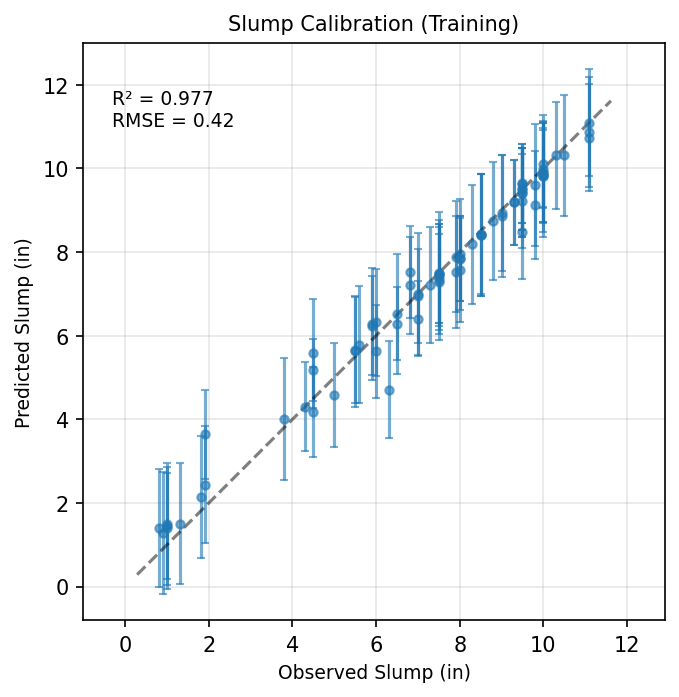

In [4]:
with torch.no_grad():
    post = slump_gp.posterior(X_slump)
    pred = post.mean.squeeze()
    std = post.variance.sqrt().squeeze()

fig = plot_slump_calibration(
    observed=Y_slump.squeeze(),
    predicted_mean=pred,
    predicted_std=std,
    title='Slump Calibration (Training)',
)
plt.show()

## 4. Leave-One-Out Cross-Validation

Efficient O(n³) LOO-CV from the fitted model without refitting.

LOO-CV R²:   0.473
LOO-CV RMSE: 2.04 in
LOO-CV MAE:  1.33 in


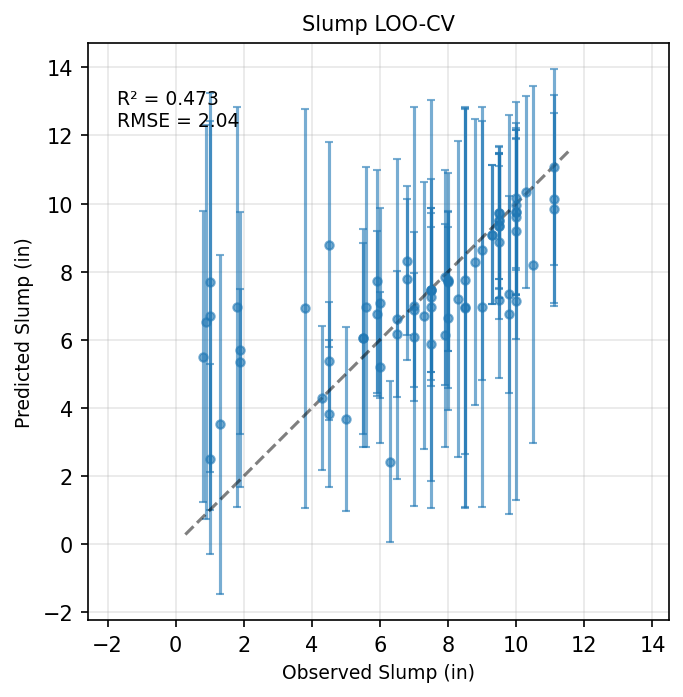

In [5]:
from linear_operator.utils.cholesky import psd_safe_cholesky

# Efficient LOO-CV via closed-form GP identity (O(n^3), no refitting)
train_X = slump_gp.train_inputs[0]
train_Y = slump_gp.train_targets
n = train_X.shape[-2]

with torch.no_grad():
    prior_dist = slump_gp.forward(train_X)
    noisy_mvn = slump_gp.likelihood(prior_dist)
    K = noisy_mvn.lazy_covariance_matrix.to_dense()

L = psd_safe_cholesky(K)
residuals = (train_Y - prior_dist.mean).unsqueeze(-1)
K_inv_res = torch.cholesky_solve(residuals, L)
I = torch.eye(n, dtype=L.dtype, device=L.device)
L_inv = torch.linalg.solve_triangular(L, I, upper=False)
K_inv_diag = (L_inv**2).sum(dim=-2)
loo_var = (1.0 / K_inv_diag).unsqueeze(-1)
loo_mean = train_Y.unsqueeze(-1) - K_inv_res * loo_var

# Untransform from standardized to original space (inches)
otf = slump_gp.outcome_transform
loo_pred = loo_mean.squeeze() * otf.stdvs.squeeze() + otf.means.squeeze()
loo_obs = train_Y * otf.stdvs.squeeze() + otf.means.squeeze()
loo_std = loo_var.squeeze().sqrt() * otf.stdvs.squeeze()  # std in original space

res = loo_pred.detach() - loo_obs
ss_res = (res**2).sum().item()
ss_tot = ((loo_obs - loo_obs.mean())**2).sum().item()
r2 = 1 - ss_res / ss_tot
rmse = (res**2).mean().sqrt().item()
mae = res.abs().mean().item()

print(f"LOO-CV R\u00b2:   {r2:.3f}")
print(f"LOO-CV RMSE: {rmse:.2f} in")
print(f"LOO-CV MAE:  {mae:.2f} in")

fig = plot_slump_calibration(
    observed=loo_obs.detach(),
    predicted_mean=loo_pred.detach(),
    predicted_std=loo_std.detach(),
    title='Slump LOO-CV',
)
plt.show()

## 5. Feature Importance

The model operates on 11 features: 10 raw composition inputs plus the derived
HRWR-to-binder ratio. The ARD lengthscales reveal which features drive slump.

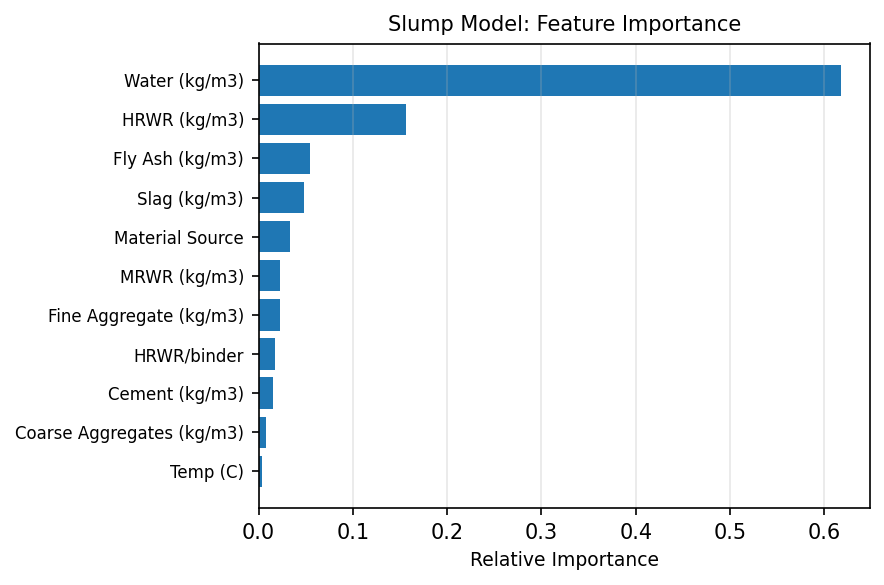

In [6]:
covar = slump_gp.covar_module
if hasattr(covar, 'base_kernel') and hasattr(covar.base_kernel, 'lengthscale'):
    lengthscales = covar.base_kernel.lengthscale.squeeze().detach()
elif hasattr(covar, 'lengthscale'):
    lengthscales = covar.lengthscale.squeeze().detach()
else:
    raise AttributeError(f'Cannot extract lengthscales from {type(covar)}')

feature_names = DEFAULT_X_COLUMNS[:-1] + ['HRWR/binder']
fig = plot_feature_importance(
    lengthscales=lengthscales,
    feature_names=feature_names,
    title='Slump Model: Feature Importance',
)
plt.show()